In [1]:
import json

with open('similar_100.json', 'r') as file:
    similar = json.loads(file.read())

with open('mask_100.json', 'r') as file:
    mask = json.loads(file.read())
    
with open('random_100.json', 'r') as file:
    random = json.loads(file.read())
    
with open('mix_30_30_40.json', 'r') as file:
    mix = json.loads(file.read())

In [2]:
EPOCH_NUMBER = 100
SAMPLES_PER_EPOCH_TRAIN = len(similar['train_loss']) // EPOCH_NUMBER
SAMPLES_PER_EPOCH_TEST = len(similar['test_loss']) // EPOCH_NUMBER

In [3]:
def get_mean_by_epoch(
    data: dict,
    train_metrics = ['train_loss', 'train_acc'],
    test_metrics = ['test_loss', 'test_acc'],
):
    mean_data = {}
    for key in data.keys():
        if key in train_metrics:
            if len(data[key]) > SAMPLES_PER_EPOCH_TRAIN:
                mean_data[key] = [sum(data[key][i:i + SAMPLES_PER_EPOCH_TRAIN]) / SAMPLES_PER_EPOCH_TRAIN for i in range(0, len(data[key]), SAMPLES_PER_EPOCH_TRAIN)]
            else:
                mean_data[key] = data[key]
        if key in test_metrics:
            if len(data[key]) > SAMPLES_PER_EPOCH_TEST:
                mean_data[key] = [sum(data[key][i:i + SAMPLES_PER_EPOCH_TEST]) / SAMPLES_PER_EPOCH_TEST for i in range(0, len(data[key]), SAMPLES_PER_EPOCH_TEST)]
            else:
                mean_data[key] = data[key]
    return mean_data

mean_similar = get_mean_by_epoch(similar)
mean_mask = get_mean_by_epoch(mask)
mean_random = get_mean_by_epoch(random)
mean_mix = get_mean_by_epoch(mix)


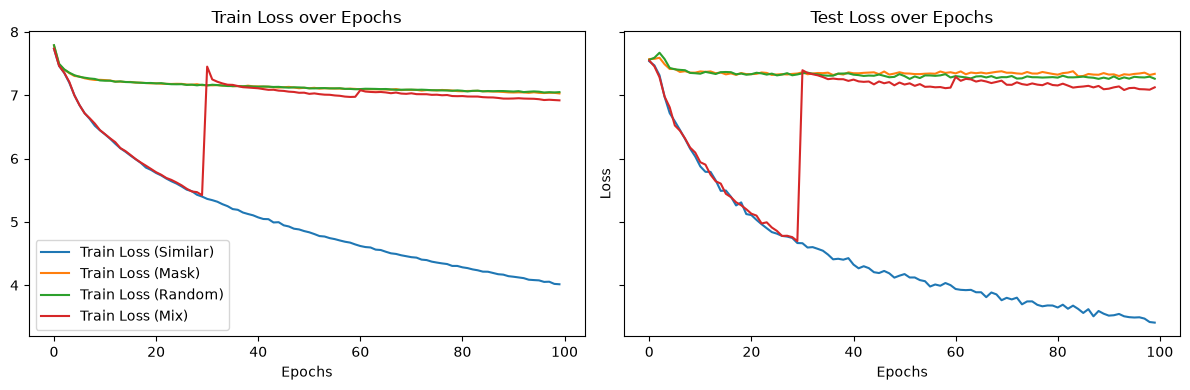

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(mean_similar['train_loss'], label='Train Loss (Similar)')
axes[0].plot(mean_mask['train_loss'], label='Train Loss (Mask)')
axes[0].plot(mean_random['train_loss'], label='Train Loss (Random)')
axes[0].plot(mean_mix['train_loss'], label='Train Loss (Mix)')
axes[0].set_title('Train Loss over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].legend()

axes[1].plot(mean_similar['test_loss'], label='Test Loss (Similar)')
axes[1].plot(mean_mask['test_loss'], label='Test Loss (Mask)')
axes[1].plot(mean_random['test_loss'], label='Test Loss (Random)')
axes[1].plot(mean_mix['test_loss'], label='Test Loss (Mix)')
axes[1].set_title('Test Loss over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[0].legend()

plt.tight_layout()
plt.show()

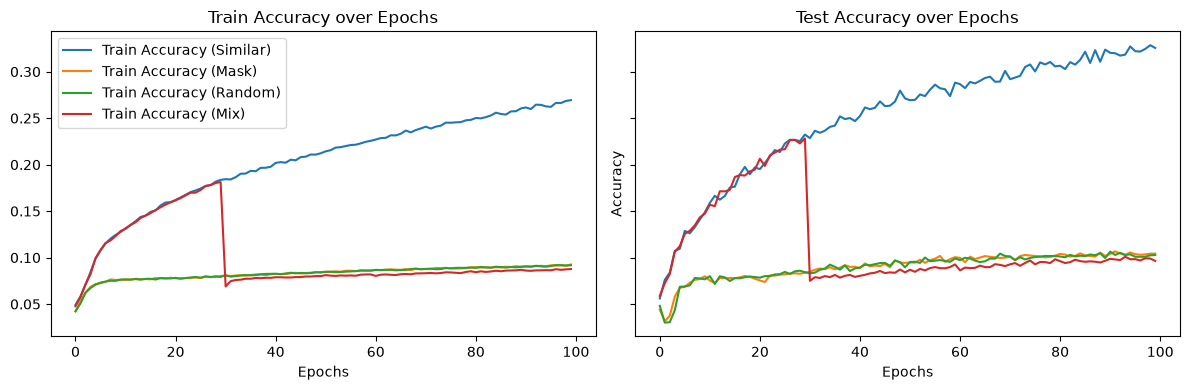

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(mean_similar['train_acc'], label='Train Accuracy (Similar)')
axes[0].plot(mean_mask['train_acc'], label='Train Accuracy (Mask)')
axes[0].plot(mean_random['train_acc'], label='Train Accuracy (Random)')
axes[0].plot(mean_mix['train_acc'], label='Train Accuracy (Mix)')
axes[0].set_title('Train Accuracy over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].legend()

axes[1].plot(mean_similar['test_acc'], label='Test Accuracy (Similar)')
axes[1].plot(mean_mask['test_acc'], label='Test Accuracy (Mask)')
axes[1].plot(mean_random['test_acc'], label='Test Accuracy (Random)')
axes[1].plot(mean_mix['test_acc'], label='Test Accuracy (Mix)')
axes[1].set_title('Test Accuracy over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[0].legend()

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

df = pd.read_json('evaluation_results.json')
df.head()

,model,model_path,dataset,split,corruption_method,corruption_rate,loss,accuracy,num_positions
0,similar_100,results/models/similar_100.pt,cimec/lambada,test,similar,0.25,4.796908,0.227557,42407
1,similar_100,results/models/similar_100.pt,cimec/lambada,test,similar,0.50,4.781611,0.228503,83964
2,similar_100,results/models/similar_100.pt,cimec/lambada,test,similar,0.75,4.788877,0.228754,125449
3,similar_100,results/models/similar_100.pt,cimec/lambada,test,similar,0.90,4.794031,0.226518,149679
4,similar_100,results/models/similar_100.pt,cimec/lambada,test,similar,0.95,4.788616,0.226872,157234


In [30]:
def compare_models_by_method(df, corruption_method, corruption_rate, metrics = ['loss', 'accuracy']):
    models = df.model.unique()
    df = df[(df['corruption_method'] == corruption_method) & (df['corruption_rate'] == corruption_rate)]
    _, axes = plt.subplots(1, 2, figsize=(12, 4))
    for i, metric in enumerate(metrics):
        axes[i].bar(x=models, height=df[metric])
        axes[i].set_title(f'{metric.capitalize()} Comparison for {corruption_method} at {corruption_rate*100}% Corruption Rate')

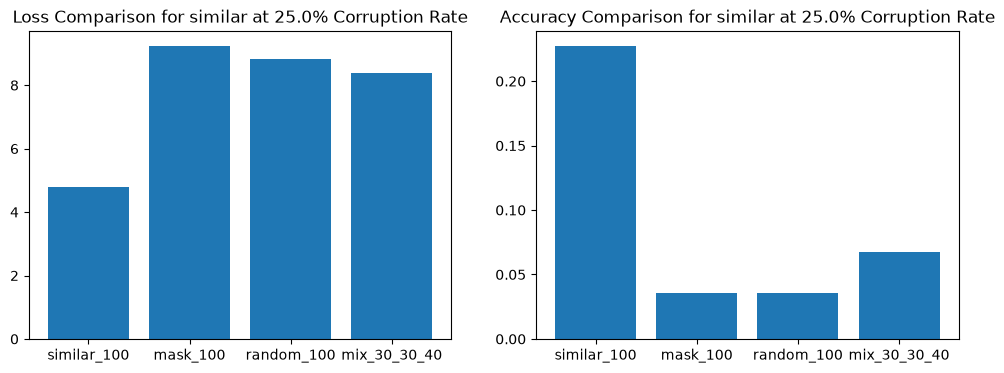

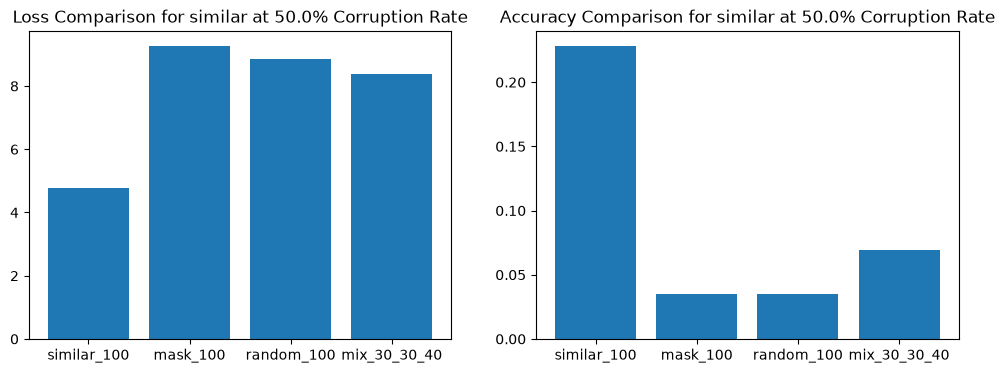

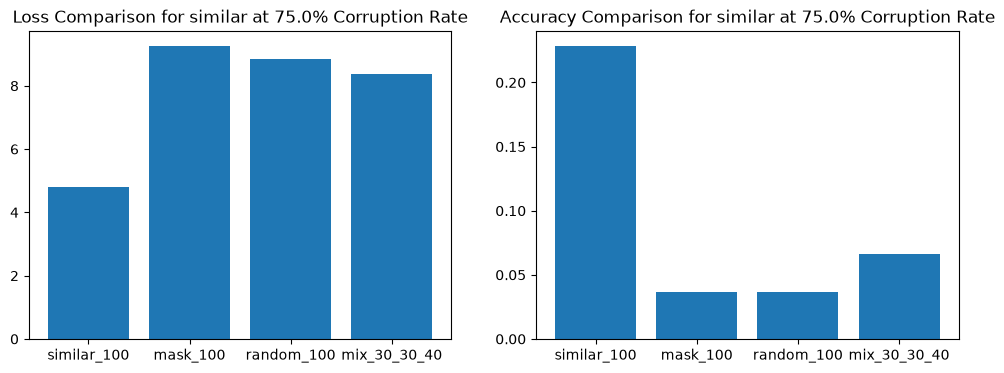

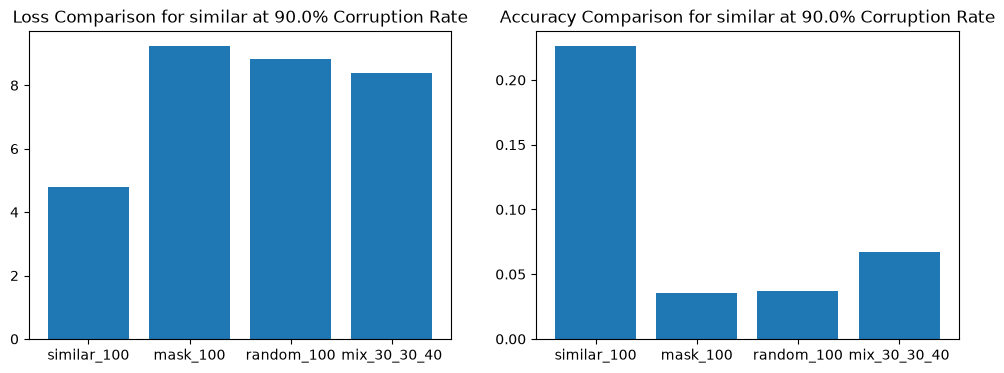

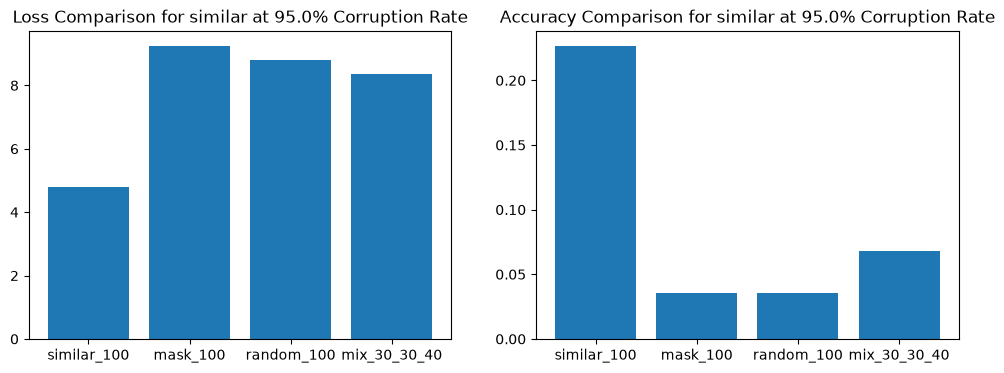

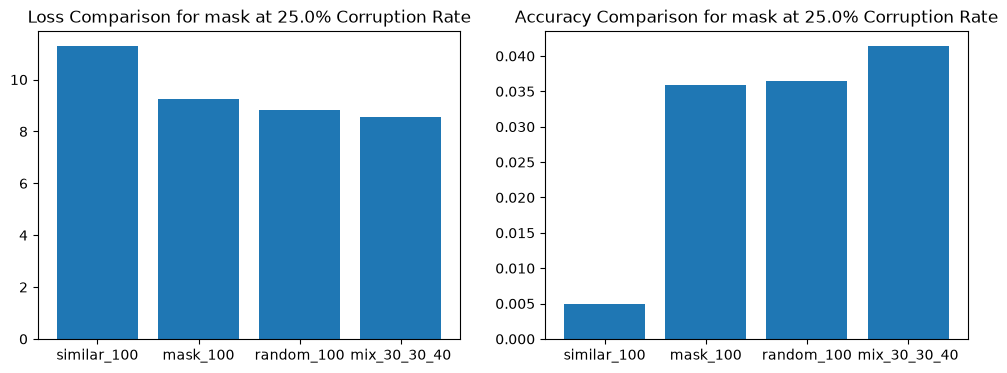

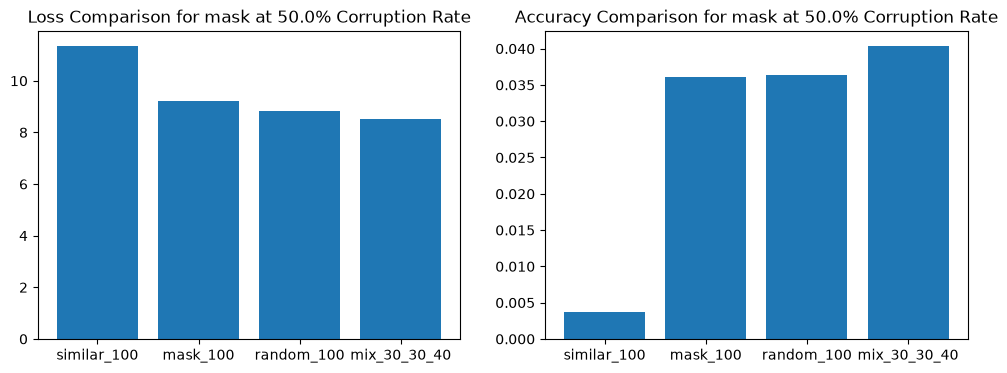

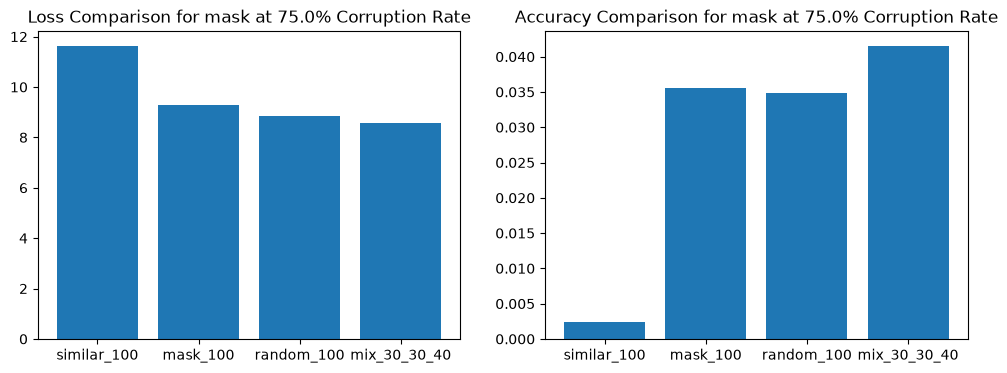

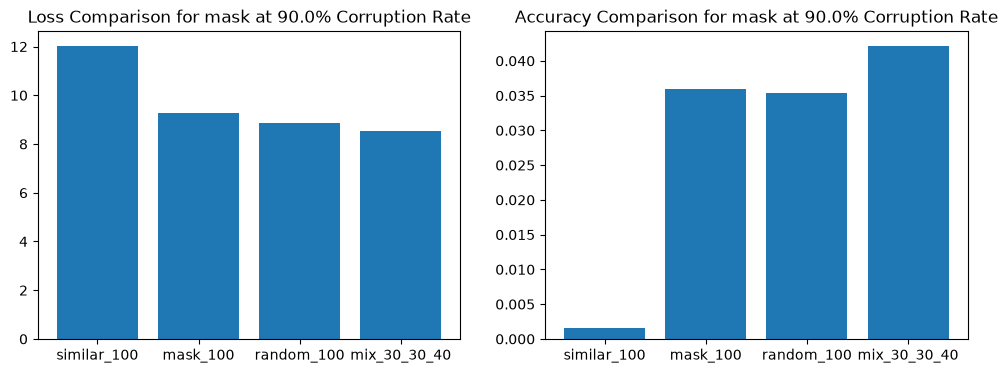

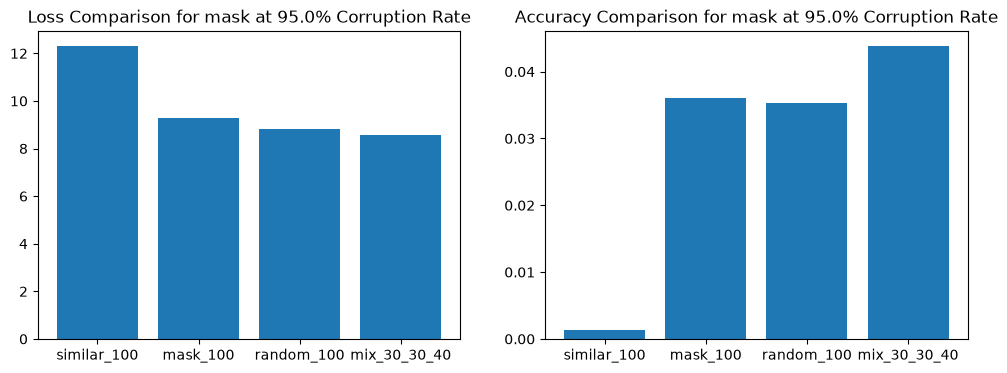

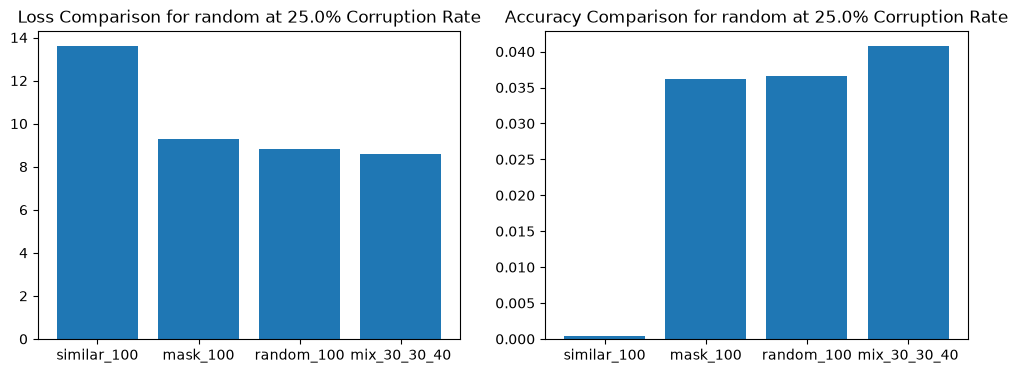

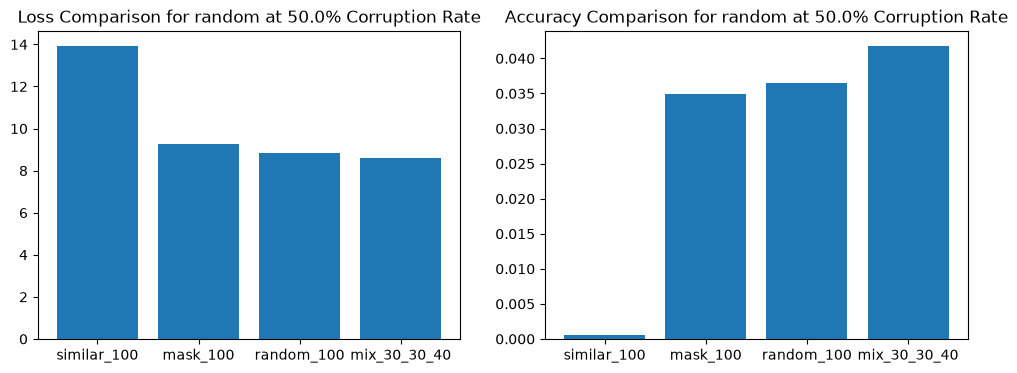

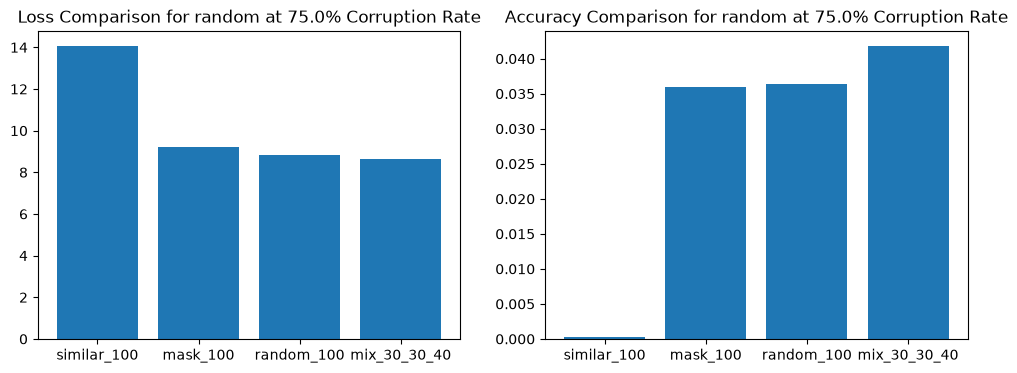

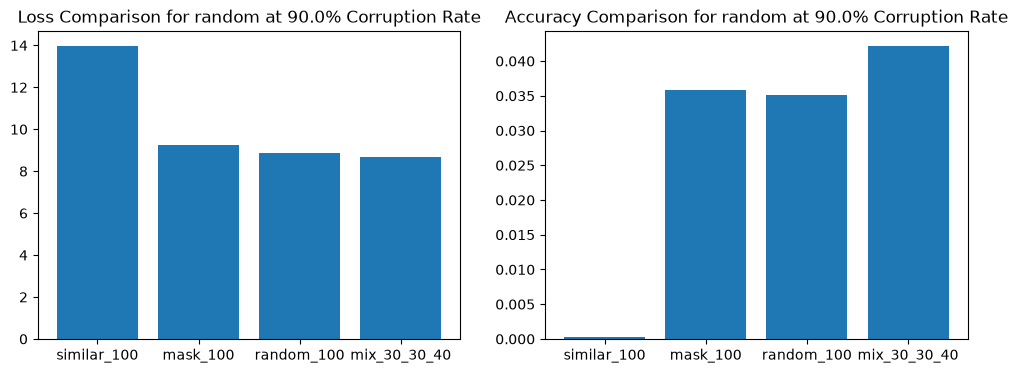

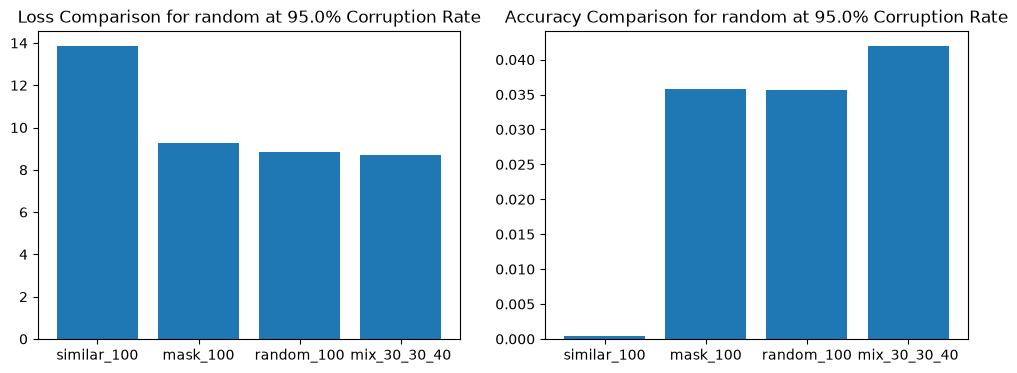

In [32]:
for corruption_method in df['corruption_method'].unique():
    for corruption_rate in df['corruption_rate'].unique():
        compare_models_by_method(df, corruption_method, corruption_rate)

In [34]:
df.groupby('model').agg({'loss': 'mean', 'accuracy': 'mean'}).reset_index().sort_values(by=['loss', 'accuracy'], ascending=[True, False])

,model,loss,accuracy
1,mix_30_30_40,8.527242,0.050383
2,random_100,8.831879,0.035896
0,mask_100,9.259278,0.035802
3,similar_100,10.142992,0.076949
